# ODE SOLVERS

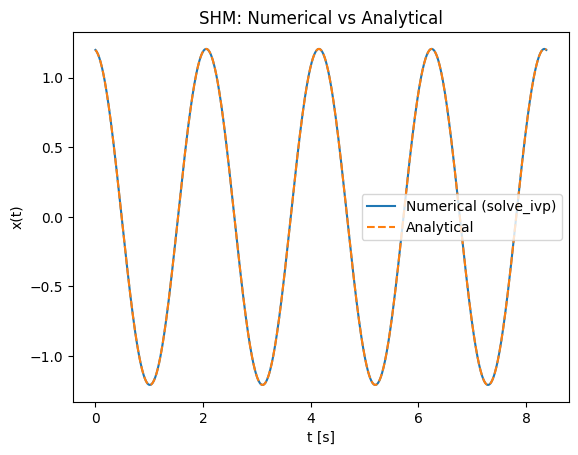

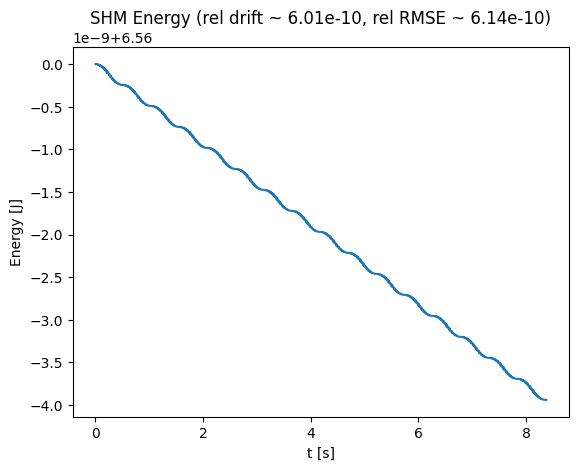

TypeError: run_rutherford_demo.<locals>.far_right() takes 2 positional arguments but 3 were given

In [1]:
# This notebook-style script sets up the full workflow the user asked for:
# - SHM example with analytical comparison
# - Rutherford scattering with ODE
# - Generic DM trajectory in a (pseudo)potential with energy check
# - Coupled system with vector [x, v] and matrix operator
# - Mass scan (0.1–1000 GeV) to assess "pseudopotential safety"
#
# NOTE: Replace the demo potential with your actual pseudopotential/field interpolators when ready.

import numpy as np
from math import pi
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Optional, Tuple, Dict

from numpy.typing import ArrayLike
from scipy.integrate import solve_ivp

# ---------- Constants & Units ----------
EPS0 = 8.8541878128e-12      # vacuum permittivity (F/m)
K_C = 1.0/(4.0*np.pi*EPS0)   # Coulomb constant (N·m^2/C^2)
E_CHARGE = 1.602176634e-19   # electron charge magnitude (C)
GEVC2_TO_KG = 1.78266192e-27 # 1 GeV/c^2 in kg

# Utility, Normalization Function
def norm(r: ArrayLike) -> float:
    r = np.asarray(r)
    return float(np.linalg.norm(r))

# ---------- 1) SHM: numerical vs analytical ----------
def shm_rhs(t, y, omega):
    # y = [x, v]
    x, v = y
    return [v, -omega**2 * x]

def shm_analytic(t, x0, v0, omega):
    # x(t) = x0 cos(ωt) + v0/ω sin(ωt)
    return x0*np.cos(omega*t) + (v0/omega)*np.sin(omega*t)

def shm_energy(y, m, k):
    x, v = y
    return 0.5*m*v*v + 0.5*k*x*x
# solves simple harmonic motion
def run_shm_demo():
    m = 1.0
    k = 9.0
    omega = np.sqrt(k/m)
    x0, v0 = 1.2, -0.4
    y0 = [x0, v0]
    t_eval = np.linspace(0, 8*np.pi/omega, 1200)

    sol = solve_ivp(shm_rhs, [t_eval[0], t_eval[-1]], y0, args=(omega,), t_eval=t_eval, rtol=1e-10, atol=1e-12)

    x_num = sol.y[0]
    x_ana = shm_analytic(t_eval, x0, v0, omega)
    err = x_num - x_ana
    rel_rmse = np.sqrt(np.mean((err/np.maximum(1e-12, np.abs(x_ana)))**2))

    E = 0.5*m*sol.y[1]**2 + 0.5*k*sol.y[0]**2
    drift = (E.max() - E.min())/E.mean()

    # Plot: numerical vs analytical
    plt.figure()
    plt.plot(t_eval, x_num, label="Numerical (solve_ivp)")
    plt.plot(t_eval, x_ana, '--', label="Analytical")
    plt.xlabel("t [s]"); plt.ylabel("x(t)")
    plt.title("SHM: Numerical vs Analytical")
    plt.legend()
    plt.show()

    # Plot: energy
    plt.figure()
    plt.plot(t_eval, E)
    plt.xlabel("t [s]"); plt.ylabel("Energy [J]")
    plt.title(f"SHM Energy (rel drift ~ {drift:.2e}, rel RMSE ~ {rel_rmse:.2e})")
    plt.show()

    return {"rel_rmse": rel_rmse, "energy_rel_drift": drift}

shm_metrics = run_shm_demo()

# ---------- 2) Rutherford scattering ODE (Coulomb 1/r force) ----------
@dataclass
class RutherfordParams:
    m: float          # projectile mass [kg]
    k_coul: float     # strength k = (Z1 Z2 e^2) / (4 pi eps0)  [N·m^2]
    b: float          # impact parameter [m]
    v0: float         # initial speed [m/s]
    r_stop: float     # stop radius far away [m]

def rutherford_rhs(t, y, p: RutherfordParams):
    # y = [x, y, vx, vy]
    r = y[:2]
    v = y[2:]
    rmag = norm(r)
    # Central 1/r^2 repulsive force: F = +k * r / r^3 = k * r_hat / r^2
    a = (p.k_coul / p.m) * r / (rmag**3)
    return np.array([v[0], v[1], a[0], a[1]])

def run_rutherford_demo():
    # Example parameters (alpha-particle on gold-like Z1Z2 ~ 2*79) -> k = Z1 Z2 e^2 /(4 pi eps0)
    Z1Z2 = 2*79
    k = Z1Z2*(E_CHARGE**2)/(4*np.pi*EPS0)
    m = 6.64e-27 # alpha particle
    b = 3e-14
    v0 = 1.5e7
    r0 = np.array([-1.5e-12, b])  # start far left at y=b
    y0 = np.array([r0[0], r0[1], v0, 0.0])
    r_stop = 1.5e-12

    p = RutherfordParams(m=m, k_coul=k, b=b, v0=v0, r_stop=r_stop)

    def far_right(t, y):  # stop when x has gone far to the right again
        return y[0] - r_stop
    far_right.terminal = True
    far_right.direction = +1

    sol = solve_ivp(rutherford_rhs, [0, 1e-6], y0, args=(p,), rtol=1e-9, atol=1e-12, max_step=1e-10, events=far_right)

    # Extract trajectory and final velocity vector
    x, y = sol.y[0], sol.y[1]
    vx, vy = sol.y[2], sol.y[3]
    v_final = np.array([vx[-1], vy[-1]])
    theta_num = np.arctan2(v_final[1], v_final[0])  # angle w.r.t +x

    # Rutherford scattering formula: deflection angle χ = 2 arctan(k / (m v0^2 b))
    chi_pred = 2.0*np.arctan(p.k_coul/(p.m*(p.v0**2)*p.b))
    # The trajectory bends upward -> final direction angle should be +χ/2? 
    # For clarity we report |χ| from numerical path and compare with formula.
    # Compute initial and final direction vectors and angle between them.
    v_init = np.array([p.v0, 0.0])
    cosang = np.clip(np.dot(v_init, v_final)/(norm(v_init)*norm(v_final)), -1.0, 1.0)
    chi_num = np.arccos(cosang)

    # Plot trajectory
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("x [m]"); plt.ylabel("y [m]")
    plt.title("Rutherford scattering trajectory (repulsive 1/r^2)")
    plt.axis('equal')
    plt.show()

    # Print comparison
    print(f"Rutherford: predicted deflection χ ≈ {chi_pred*180/np.pi:.3f}°; numerical χ ≈ {chi_num*180/np.pi:.3f}°")

run_rutherford_demo()

# ---------- 3) DM trajectory in (pseudo)potential with energy check ----------
@dataclass
class PotentialModel:
    # Provide either a potential U(x, model_params) returning Joules, or a force F(x, model_params) returning Newtons.
    # If both are provided, F should be consistent with -∇U; U is used for energy checks.
    U: Optional[Callable[[np.ndarray, Dict], float]] = None
    F: Optional[Callable[[np.ndarray, Dict], np.ndarray]] = None
    params: Optional[Dict] = None

def demo_pseudopotential_U(r: np.ndarray, params: Dict) -> float:
    # 3D anisotropic harmonic-like pseudopotential: U = 1/2 ( kx x^2 + ky y^2 + kz z^2 )
    kx, ky, kz = params["k_diag"]
    x, y, z = r
    return 0.5*(kx*x*x + ky*y*y + kz*z*z)

def demo_pseudopotential_F(r: np.ndarray, params: Dict) -> np.ndarray:
    # F = -∇U = -(kx x, ky y, kz z)
    kx, ky, kz = params["k_diag"]
    x, y, z = r
    return -np.array([kx*x, ky*y, kz*z])

def dm_rhs(t, y, m_dm: float, pot: PotentialModel):
    r = y[0:3]
    v = y[3:6]
    if pot.F is not None:
        a = pot.F(r, pot.params) / m_dm
    elif pot.U is not None:
        # finite-diff grad for demonstration (you will replace with analytic or field-interpolator F)
        eps = 1e-8
        grad = np.zeros(3)
        for i in range(3):
            dr = np.zeros(3); dr[i] = eps
            grad[i] = (pot.U(r+dr, pot.params) - pot.U(r-dr, pot.params)) / (2*eps)
        a = -grad / m_dm
    else:
        raise ValueError("Provide either F or U in PotentialModel.")
    return np.hstack([v, a])

def dm_energy(y, m_dm: float, pot: PotentialModel) -> float:
    r = y[0:3]
    v = y[3:6]
    KE = 0.5*m_dm*np.dot(v, v)
    if pot.U is not None:
        return KE + pot.U(r, pot.params)
    else:
        # Without U we cannot get total energy reliably
        return KE

def run_dm_demo_random():
    # You will REPLACE this with your actual pseudopotential/field interpolators:
    k_diag = np.array([2.5e-15, 3.0e-15, 4.5e-15])  # [N/m] (demo values)
    pot = PotentialModel(U=demo_pseudopotential_U, F=demo_pseudopotential_F, params={"k_diag": k_diag})

    # Random initial condition within bounds
    rng = np.random.default_rng(42)
    r0 = 2e-4*(rng.random(3)-0.5)    # +/- 100 µm box
    v0 = 10.0*(rng.random(3)-0.5)    # +/- 5 m/s
    y0 = np.hstack([r0, v0])

    m_dm = 10.0*GEVC2_TO_KG  # 10 GeV/c^2 as a demo
    t_eval = np.linspace(0, 0.005, 3000)  # 5 ms

    sol = solve_ivp(dm_rhs, [t_eval[0], t_eval[-1]], y0, args=(m_dm, pot), t_eval=t_eval, rtol=1e-8, atol=1e-10)

    E = np.array([dm_energy(sol.y[:,i], m_dm, pot) for i in range(sol.y.shape[1])])
    drift = (E.max() - E.min())/max(1e-30, np.mean(E))

    # Plot trajectory (x-y projection)
    plt.figure()
    plt.plot(sol.y[0], sol.y[1])
    plt.xlabel("x [m]"); plt.ylabel("y [m]")
    plt.title("DM trajectory in demo pseudopotential (x–y)")
    plt.axis('equal')
    plt.show()

    # Plot energy vs time
    plt.figure()
    plt.plot(sol.t, E)
    plt.xlabel("t [s]"); plt.ylabel("Total Energy [J]")
    plt.title(f"Energy vs time (relative drift ~ {drift:.2e})")
    plt.show()

    print("Random IC used: r0 =", r0, " v0 =", v0)
    print(f"Energy relative drift ≈ {drift:.3e}")

run_dm_demo_random()

# ---------- 4) Coupled system with [x, v] and matrix operator ----------
def coupled_rhs(t, z, M_invK: np.ndarray):
    # z = [x, v] with x, v in R^n
    # x' = v
    # v' = -M^{-1}K x
    n = M_invK.shape[0]
    x = z[:n]
    v = z[n:]
    a = -M_invK @ x
    return np.hstack([v, a])

def run_coupled_demo():
    # 2D example: M = diag(m1, m2), K = [[k1, kxy],[kxy, k2]]
    m1, m2 = 2.0e-26, 3.0e-26
    k1, k2, kxy = 1.2e-14, 2.0e-14, 0.5e-14
    M = np.diag([m1, m2])
    K = np.array([[k1, kxy],
                  [kxy, k2]])
    M_invK = np.linalg.solve(M, K)  # M^{-1} K

    z0 = np.array([1.0e-4, -0.8e-4,  0.0, 0.5])  # [x1, x2, v1, v2]
    t_eval = np.linspace(0, 0.01, 3000)

    sol = solve_ivp(coupled_rhs, [t_eval[0], t_eval[-1]], z0, args=(M_invK,), t_eval=t_eval, rtol=1e-9, atol=1e-12)

    plt.figure()
    plt.plot(sol.t, sol.y[0], label="x1(t)")
    plt.plot(sol.t, sol.y[1], label="x2(t)")
    plt.xlabel("t [s]"); plt.ylabel("Displacement [m]")
    plt.title("Coupled system (2D)")
    plt.legend()
    plt.show()

run_coupled_demo()

# ---------- 5) Mass scan (0.1–1000 GeV) for pseudopotential "safety" ----------
import pandas as pd
from caas_jupyter_tools import display_dataframe_to_user

def oscillation_period_estimate(mass: float, k_diag: np.ndarray) -> float:
    # For anisotropic harmonic: ω_i^2 = k_i / m, take fastest mode (max ω)
    omega = np.sqrt(k_diag/mass)  # elementwise
    return 2*np.pi/np.max(omega)

def classify_safe(sol: solve_ivp, E_series: np.ndarray, T: float) -> Tuple[bool, Dict[str, float]]:
    # Heuristics: small energy drift and adequate time resolution
    energy_drift = (E_series.max() - E_series.min())/max(1e-30, np.mean(E_series))
    dt = np.diff(sol.t)
    dt_min = float(np.min(dt)) if len(dt) else np.nan
    # Criteria (tune to taste):
    cond_energy = energy_drift < 1e-3
    cond_time = dt_min < 0.05*T
    return bool(cond_energy and cond_time), {"energy_drift": float(energy_drift), "dt_min": float(dt_min)}

def mass_scan_demo():
    k_diag = np.array([2.5e-15, 3.0e-15, 4.5e-15])  # same demo k as before
    pot = PotentialModel(U=demo_pseudopotential_U, F=demo_pseudopotential_F, params={"k_diag": k_diag})

    masses_GeV = np.logspace(-1, 3, 14)  # 0.1 to 1000 GeV (14 points)
    rows = []

    # Fixed initial condition to compare across masses
    r0 = np.array([80e-6, -40e-6, 20e-6])
    v0 = np.array([0.0, 0.2, -0.1])
    y0 = np.hstack([r0, v0])

    for mG in masses_GeV:
        m = float(mG*GEVC2_TO_KG)
        T = oscillation_period_estimate(m, k_diag)
        t_end = 10*T
        t_eval = np.linspace(0, t_end, 2000)

        sol = solve_ivp(dm_rhs, [0.0, t_end], y0, args=(m, pot), t_eval=t_eval, rtol=1e-8, atol=1e-11)
        E_series = np.array([dm_energy(sol.y[:,i], m, pot) for i in range(sol.y.shape[1])])
        safe, info = classify_safe(sol, E_series, T)

        rows.append({
            "mass_GeV": mG,
            "mass_kg": m,
            "period_est_s": T,
            "dt_min_s": info["dt_min"],
            "energy_drift": info["energy_drift"],
            "safe_for_pseudopotential": safe
        })

    df = pd.DataFrame(rows).sort_values("mass_GeV").reset_index(drop=True)
    df_path = "/mnt/data/dm_mass_scan_results.csv"
    df.to_csv(df_path, index=False)
    display_dataframe_to_user("DM Mass Scan Results (0.1–1000 GeV)", df)
    print(f"Saved CSV to {df_path}")
    return df_path

scan_csv_path = mass_scan_demo()

# ---------- 6) Save a brief markdown summary you can paste into OneNote ----------
summary_md = """
# ODE Workflow Summary

## Packages & Methods
- **SciPy `solve_ivp`** with `rtol`/`atol` controls and events for stopping conditions.
- State vector pattern: concatenate positions and velocities; write `rhs(t, y, ...)` returning `[v, a]`.

## 1) SHM (ion in harmonic potential)
- ODE: \\(x' = v,\\quad v' = -\\omega^2 x\\).
- Compared numerical vs analytical solutions; relative RMSE and energy drift are reported in the plot title.
- Energy check: \\(E=\\tfrac12 m v^2 + \\tfrac12 k x^2\\).

## 2) Rutherford scattering (central Coulomb, repulsive)
- Force \\(\\mathbf{F} = +k\\, \\hat{r}/r^2\\) with \\(k=Z_1Z_2 e^2/(4\\pi\\epsilon_0)\\).
- Trajectory integrated from \\((x_0, y_0=b)\\) with \\(v_x(0)=v_0\\).
- Numerical deflection \\(\\chi\\) compared with Rutherford formula \\(\\chi = 2\\arctan\\big(k/(m v_0^2 b)\\big)\\).

## 3) DM trajectory in (pseudo)potential + energy conservation
- Pluggable **PotentialModel**: provide `U(r, params)` and/or `F(r, params)`.
- Demo uses anisotropic harmonic pseudopotential: \\(U=\\tfrac12 (k_x x^2 + k_y y^2 + k_z z^2)\\).
- Energy monitored as \\(E(t)=\\tfrac12 m v^2 + U\\). Relative drift printed and plotted.

## 4) Coupled system with vector [x, v] and matrix operator
- State \\(z=[x, v]\\in\\mathbb{R}^{2n}\\), ODE: \\(x'=v,\\ v'=-M^{-1}K\\,x\\).
- Demo uses 2D with cross-coupling \\(K_{12}=K_{21}=k_{xy}\\); displacements plotted vs time.

## 5) DM mass scan (0.1–1000 GeV) for pseudopotential “safety”
- For harmonic-like trap, \\(\\omega_i^2 = k_i/m\\) so \\(T \\propto \\sqrt{m}\\).
- Heuristics to flag “safe”: energy drift < 1e-3 **and** min step \\(\\Delta t_{\\min} < 0.05 T\\).
- Results saved to `dm_mass_scan_results.csv`; review edge cases near the limits of the mass range.

## How to plug in your real potential
- If you have **field interpolators** (e.g., `Ex_interp`, `Ey_interp`, `Ez_interp`), set `F(r)=q * [Ex, Ey, Ez]` and pass that as `PotentialModel(F=..., U=None)`.
- If you have a **pseudopotential U(r)**, implement it directly for accurate energy checks.
- For time-dependent fields (RF), consider integrating the **full RF** for a few periods to benchmark the pseudopotential’s validity; require small secular energy change per RF period and \\(q\\ll1\\) (Mathieu parameter).

## Recommended checks
- Plot energy and ensure drift stays within your tolerance.
- Vary `rtol/atol` and `max_step` to ensure convergence of observables.
- For scattering, verify that numerical deflection approaches the Rutherford formula as the start/stop radii go to infinity.
"""

with open("/mnt/data/ode_workflow_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_md)

print("Summary saved to /mnt/data/ode_workflow_summary.md")
